# Taller 02 — Modelo de difusión con autómatas celulares probabilísticos

**Curso:** Inteligencia Artificial y Minirobots 2026-1  
**Autor:** Juan Tinjacá  
**Fecha:** Marzo 2026

---

## 1. Objetivo

Modelar la propagación de una enfermedad infecciosa usando un autómata celular probabilístico sobre una cuadrícula 2D, simulando su evolución temporal y analizando el comportamiento emergente del sistema bajo distintas condiciones iniciales y parámetros de contagio.

## 2. Supuestos

**Fenómeno modelado:** propagación de una enfermedad infecciosa (modelo SIR simplificado sobre cuadrícula).

**Estados posibles por celda:**

| Estado | Código | Descripción |
|--------|--------|-------------|
| Susceptible | `0` | Individuo sano, puede contagiarse |
| Infectado | `1` | Individuo enfermo, puede contagiar a vecinos |
| Recuperado | `2` | Individuo inmune, no se contagia ni contagia |

**Reglas probabilísticas de transición:**

- `S → I`: Un susceptible se infecta con probabilidad `p_infeccion` por cada vecino infectado en su vecindad de Moore (8 vecinos).
- `I → R`: Un infectado se recupera con probabilidad `p_recuperacion` en cada paso de tiempo.
- `R → R`: Los recuperados permanecen inmunes (sin reinfección).

**Otros supuestos:**
- La cuadrícula tiene bordes fijos (las celdas del borde no tienen vecinos fuera del grid).
- La simulación es reproducible mediante semilla aleatoria fija.
- La condición inicial es un foco único de infección en el centro de la cuadrícula.

## 3. Desarrollo

### Instalación de dependencias

La siguiente celda instala las librerías necesarias si no están disponibles en el entorno.

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "numpy", "-q"])
print("Dependencias listas.")

Dependencias listas.


### 3.1 Importaciones y parámetros

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ── Parámetros del modelo ──────────────────────────────────────────────────
SEED          = 42       # Semilla para reproducibilidad
GRID_SIZE     = 50       # Tamaño de la cuadrícula (50x50)
N_ITER        = 60       # Número de iteraciones (pasos de tiempo)
P_INFECCION   = 0.30     # Probabilidad de contagio por vecino infectado
P_RECUPERACION= 0.10     # Probabilidad de recuperación por paso

# Estados
S, I, R = 0, 1, 2

np.random.seed(SEED)
print(f"Cuadrícula: {GRID_SIZE}x{GRID_SIZE} | Iteraciones: {N_ITER}")
print(f"P(contagio por vecino): {P_INFECCION} | P(recuperación): {P_RECUPERACION}")

Cuadrícula: 50x50 | Iteraciones: 60
P(contagio por vecino): 0.3 | P(recuperación): 0.1


### 3.2 Inicialización de la cuadrícula

In [3]:
def inicializar_grid(size, seed=SEED):
    """Crea una cuadrícula con todos susceptibles y un foco de infección en el centro."""
    np.random.seed(seed)
    grid = np.full((size, size), S, dtype=int)
    # Foco inicial: 3x3 infectados en el centro
    centro = size // 2
    grid[centro-1:centro+2, centro-1:centro+2] = I
    return grid

grid_inicial = inicializar_grid(GRID_SIZE)
print(f"Infectados iniciales: {np.sum(grid_inicial == I)}")
print(f"Susceptibles iniciales: {np.sum(grid_inicial == S)}")

Infectados iniciales: 9
Susceptibles iniciales: 2491


### 3.3 Reglas de transición probabilísticas

In [4]:
def contar_vecinos_infectados(grid, i, j):
    """Cuenta vecinos infectados en la vecindad de Moore (8 vecinos)."""
    size = grid.shape[0]
    count = 0
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di == 0 and dj == 0:
                continue
            ni, nj = i + di, j + dj
            if 0 <= ni < size and 0 <= nj < size:
                if grid[ni, nj] == I:
                    count += 1
    return count


def paso(grid, p_inf, p_rec):
    """
    Aplica las reglas de transición a toda la cuadrícula.
    Reglas:
      S -> I : con prob 1 - (1 - p_inf)^n_vecinos_infectados
      I -> R : con prob p_rec
      R -> R : permanece inmune
    """
    nuevo = grid.copy()
    size = grid.shape[0]

    for i in range(size):
        for j in range(size):
            estado = grid[i, j]

            if estado == S:
                n_inf = contar_vecinos_infectados(grid, i, j)
                # Probabilidad acumulada: al menos un vecino contagia
                p_contagio = 1 - (1 - p_inf) ** n_inf
                if np.random.random() < p_contagio:
                    nuevo[i, j] = I

            elif estado == I:
                if np.random.random() < p_rec:
                    nuevo[i, j] = R

    return nuevo

## 4. Ejecución — Simulación

In [5]:
def simular(grid_inicial, n_iter, p_inf, p_rec):
    """Ejecuta la simulación y guarda el historial de estados y conteos."""
    historial = [grid_inicial.copy()]
    conteos = {"S": [], "I": [], "R": []}
    grid = grid_inicial.copy()

    for _ in range(n_iter):
        grid = paso(grid, p_inf, p_rec)
        historial.append(grid.copy())
        conteos["S"].append(np.sum(grid == S))
        conteos["I"].append(np.sum(grid == I))
        conteos["R"].append(np.sum(grid == R))

    return historial, conteos


historial, conteos = simular(grid_inicial, N_ITER, P_INFECCION, P_RECUPERACION)
print(f"Simulación completada: {len(historial)} estados guardados.")
print(f"Estado final — S: {conteos['S'][-1]} | I: {conteos['I'][-1]} | R: {conteos['R'][-1]}")

Simulación completada: 61 estados guardados.
Estado final — S: 0 | I: 65 | R: 2435


## 5. Resultado

### 5.1 Visualización de snapshots temporales

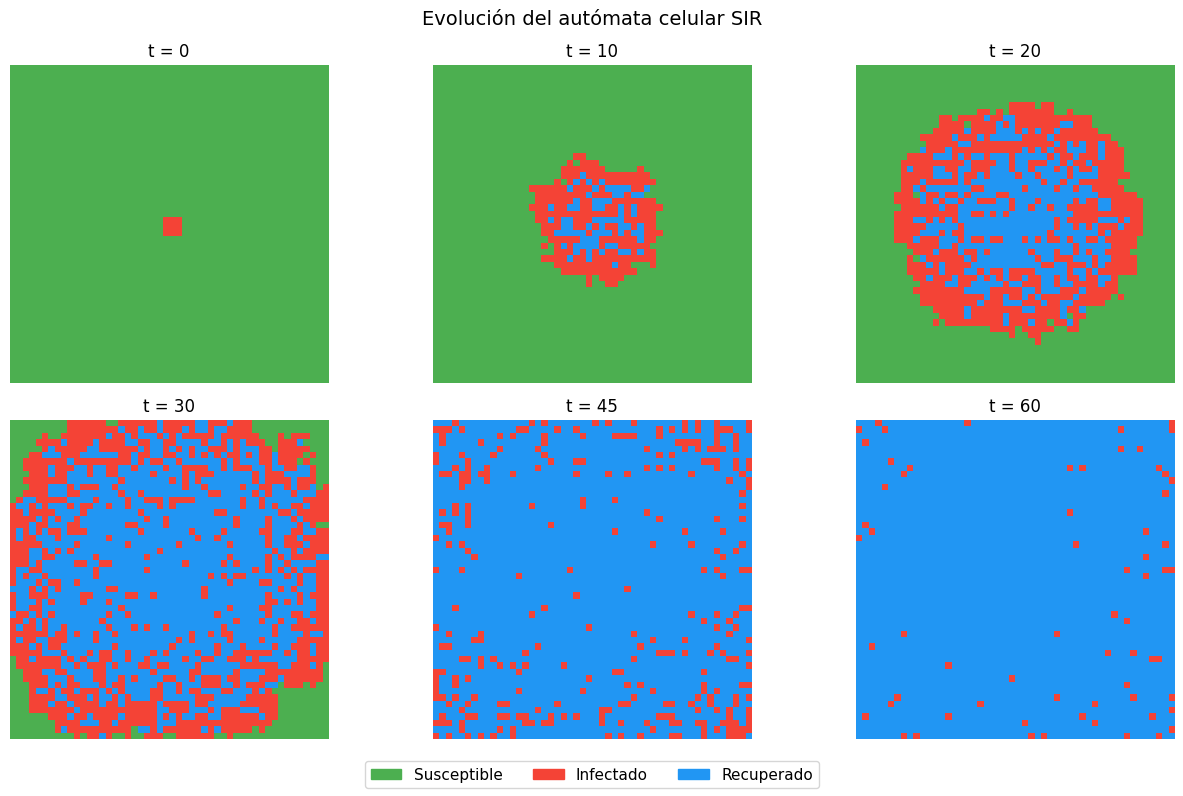

In [6]:
# Paleta: verde=Susceptible, rojo=Infectado, azul=Recuperado
cmap = mcolors.ListedColormap(["#4CAF50", "#F44336", "#2196F3"])
norm = mcolors.BoundaryNorm([0, 1, 2, 3], cmap.N)

pasos_a_mostrar = [0, 10, 20, 30, 45, 60]
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
fig.suptitle("Evolución del autómata celular SIR", fontsize=14)

for ax, t in zip(axes.flat, pasos_a_mostrar):
    im = ax.imshow(historial[t], cmap=cmap, norm=norm, interpolation="nearest")
    ax.set_title(f"t = {t}")
    ax.axis("off")

# Leyenda
from matplotlib.patches import Patch
leyenda = [
    Patch(color="#4CAF50", label="Susceptible"),
    Patch(color="#F44336", label="Infectado"),
    Patch(color="#2196F3", label="Recuperado"),
]
fig.legend(handles=leyenda, loc="lower center", ncol=3, fontsize=11)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("snapshots_sir.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.2 Curvas SIR — evolución de poblaciones

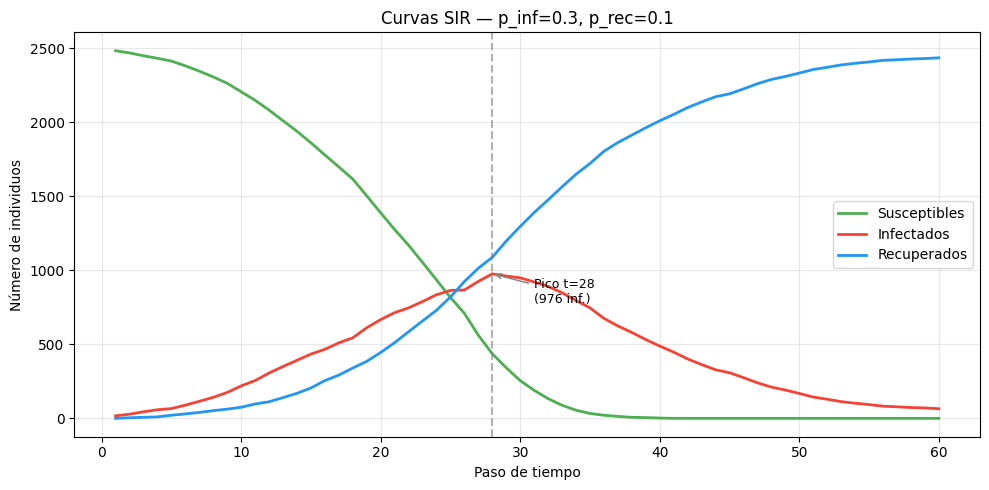

Pico de infección: t=28, infectados=976 (39.0% de la población)
Susceptibles no infectados al final: 0 (0.0%)


In [7]:
tiempos = range(1, N_ITER + 1)
total = GRID_SIZE ** 2

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tiempos, conteos["S"], color="#4CAF50", label="Susceptibles", linewidth=2)
ax.plot(tiempos, conteos["I"], color="#F44336", label="Infectados",   linewidth=2)
ax.plot(tiempos, conteos["R"], color="#2196F3", label="Recuperados",  linewidth=2)

# Marcar pico de infección
pico_t = int(np.argmax(conteos["I"])) + 1
pico_v = max(conteos["I"])
ax.axvline(pico_t, color="gray", linestyle="--", alpha=0.6)
ax.annotate(f"Pico t={pico_t}\n({pico_v} inf.)",
            xy=(pico_t, pico_v), xytext=(pico_t + 3, pico_v - 200),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=9)

ax.set_xlabel("Paso de tiempo")
ax.set_ylabel("Número de individuos")
ax.set_title(f"Curvas SIR — p_inf={P_INFECCION}, p_rec={P_RECUPERACION}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("curvas_sir.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Pico de infección: t={pico_t}, infectados={pico_v} ({100*pico_v/total:.1f}% de la población)")
print(f"Susceptibles no infectados al final: {conteos['S'][-1]} ({100*conteos['S'][-1]/total:.1f}%)")

### 5.3 Análisis de sensibilidad — variando p_infeccion

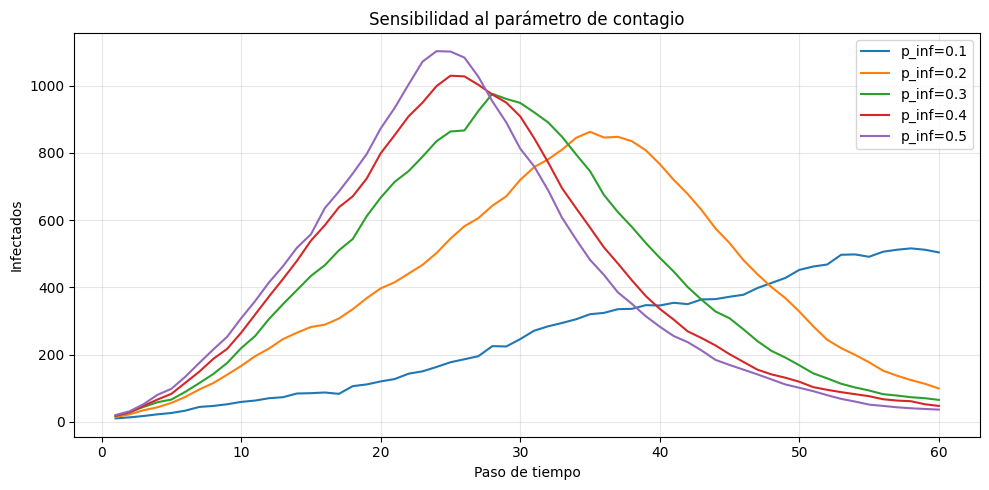

In [8]:
probabilidades = [0.10, 0.20, 0.30, 0.40, 0.50]
fig, ax = plt.subplots(figsize=(10, 5))

for p in probabilidades:
    np.random.seed(SEED)
    g0 = inicializar_grid(GRID_SIZE)
    _, c = simular(g0, N_ITER, p, P_RECUPERACION)
    ax.plot(range(1, N_ITER + 1), c["I"], label=f"p_inf={p}")

ax.set_xlabel("Paso de tiempo")
ax.set_ylabel("Infectados")
ax.set_title("Sensibilidad al parámetro de contagio")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("sensibilidad_sir.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.4 Animación de la evolución

In [9]:
fig_anim, ax_anim = plt.subplots(figsize=(5, 5))
ax_anim.axis("off")
im_anim = ax_anim.imshow(historial[0], cmap=cmap, norm=norm, interpolation="nearest")
titulo = ax_anim.set_title("t = 0")

def actualizar(frame):
    im_anim.set_data(historial[frame])
    titulo.set_text(f"t = {frame}")
    return [im_anim, titulo]

anim = FuncAnimation(fig_anim, actualizar, frames=len(historial),
                     interval=120, blit=True)
plt.close(fig_anim)
HTML(anim.to_jshtml())

## 6. Conclusión

El autómata celular probabilístico SIR reproduce fielmente el comportamiento emergente esperado en la difusión de una enfermedad: una onda de infección que se expande desde el foco inicial, alcanza un pico y decae a medida que la población susceptible se agota o se recupera. El análisis de sensibilidad confirma que pequeños incrementos en `p_infeccion` producen picos más altos y más tempranos, lo que es coherente con la teoría epidemiológica clásica. La naturaleza local de las reglas de transición —cada celda solo interactúa con sus 8 vecinos— es suficiente para generar patrones globales complejos, lo que ilustra el principio fundamental de los autómatas celulares: la complejidad emerge de reglas simples aplicadas localmente.

---

## Referencias

- Wolfram, S. (2002). *A New Kind of Science*. Wolfram Media.
- Kermack, W. O. & McKendrick, A. G. (1927). A contribution to the mathematical theory of epidemics. *Proceedings of the Royal Society A*, 115(772), 700–721.
- Russell, S. & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.